# Building Exposure Comparison

Maps and compiles **total building-exposure values** for a target country across seven
datasets, with all monetary figures aligned to **constant latest-year US$** (WDI US GDP
deflator):

| Source | Metric | Native form | Price base | Technical docs |
|---|---|---|---|---|
| **GAR15** (UNISDR GEG-15) | capital stock (structures, no contents) | ~5 km point grid | 2005 US$ | [De Bono & Chatenoux 2015](https://www.preventionweb.net/english/hyogo/gar/2015/en/bgdocs/risk-section/De%20Bono,%20Andrea,%20Bruno%20Chatenoux.%202015.%20A%20Global%20Exposure%20Model%20for%20GAR%202015,%20%20UNEP-GRID.pdf) |
| **GIRI** BEM | building stock value (no contents; res / non-res) | 5x5 km rasters | 2018 US$ | [BEM report 2023](https://giri.unepgrid.ch/sites/default/files/2023-09/GIRI_BEM_report_UNIGE.pdf) |
| **GEM v2023.1.1** | replacement cost (excl. contents) + floor area | per-country ADM1 CSV | 2021 US$ | [Yepes-Estrada et al. 2023](https://onlinelibrary.wiley.com/doi/10.1177/87552930231194048) |
| **GEM v2026.0.0** | as above, stock to 2025 | global ADM1 x taxonomy CSV | 2024 US$ | [release notes](https://github.com/gem/global_exposure_model/releases/tag/v2026.0.0) |
| **Overture** Maps | count, footprint; floor + value *estimated* | per-building footprints | (UCC 2024 US$) | [buildings schema](https://docs.overturemaps.org/guides/buildings/) |
| **GBA** LoD1 | count, footprint, volume, floor + value *estimated* | footprints + heights | (UCC 2024 US$) | [GlobalBuildingAtlas paper](https://essd.copernicus.org/articles/17/6647/2025/essd-17-6647-2025.html) |
| **Microsoft** GlobalML | count, footprint; floor + value *estimated* | footprints | (UCC 2024 US$) | [GlobalMLBuildingFootprints](https://github.com/microsoft/GlobalMLBuildingFootprints) |

Estimated values = floor area x GEM-derived ADM1 unit construction cost
([UCC-database](https://github.com/aaronopdyke/UCC-database), 2024 US$). **Storey
estimation**: Overture and Microsoft are footprint datasets in Morocco (Overture's
attributes are sparse; Microsoft's height field is -1 everywhere), so their floor areas use
reported attributes where present plus a **GBA-calibrated storey multiplier**
(GBA floor/footprint ratio per ADM1 x urban/rural class) for the rest - no 1-storey
assumption. Google Open Buildings v3 is excluded: no Morocco coverage (77 buildings).

**Comparability**: GAR15 and GIRI value *structures only*, so GEM is shown *excluding
contents* throughout. All zonal statistics use WB Official Boundaries Admin-1, with
**Western Sahara as one whole hatched unit (`ESH000`)**. All maps share one style:
Carto basemap, semi-transparent fills, data clipped to the country boundary.

In [1]:
# ================= Target country =================
TARGET_ISO = 'MAR'      # <-- select ISO3 here ('MAR', 'COL', 'NPL', ...)
# ==================================================

import os, sys, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from src.config import DATA_ROOT, OUTPUTS_DIR, FIGURES_DIR
from src.boundaries import admin1, plot_admin1
from src import buildings, deflate, gar15, gem, giri, ucc, util

try:
    import contextily as cx
    BASEMAP = cx.providers.CartoDB.PositronNoLabels
except Exception:
    cx = None
print('DATA_ROOT :', DATA_ROOT)

USD_YEAR = deflate.target_year()
F = {m: v['factor'] for m, v in deflate.model_factors().items()}
print(f'constant {USD_YEAR} US$ factors:', F)

def usd(v):
    return f'${v / 1e9:,.1f}B'

def add_basemap(ax):
    """Semi-transparent Carto basemap under the data (skips if offline)."""
    if cx is None:
        return
    try:
        cx.add_basemap(ax, crs='EPSG:4326', source=BASEMAP,
                       attribution=False, zorder=0)
    except Exception:
        pass

def style_map(ax, title):
    ax.set_title(title, fontsize=12, fontweight='bold', color='#17406D')
    ax.set_axis_off()

def choropleth(gdf, col, title, label, cmap='viridis', ax=None):
    """ADM1 choropleth: shared style - basemap, alpha fill, hatched ESH."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))
    gdf.plot(column=col, ax=ax, cmap=cmap, legend=True, alpha=0.85,
             edgecolor='#555', linewidth=0.5, zorder=2,
             legend_kwds={'shrink': 0.6, 'label': label})
    esh = gdf[gdf['ADM1CD_c'] == 'ESH000']
    if len(esh):
        esh.plot(ax=ax, facecolor='none', edgecolor='#776',
                 hatch='//', linewidth=1.0, zorder=3)
    add_basemap(ax)
    style_map(ax, title)
    return ax

DATA_ROOT : G:/My Drive/World Bank/Exposure Analytics
constant 2025 US$ factors: {'gar15': 1.581, 'giri': 1.2605, 'gem2023': 1.1702, 'gem2026': 1.028, 'ucc': 1.028}


12 admin-1 units (ESH appended: True)


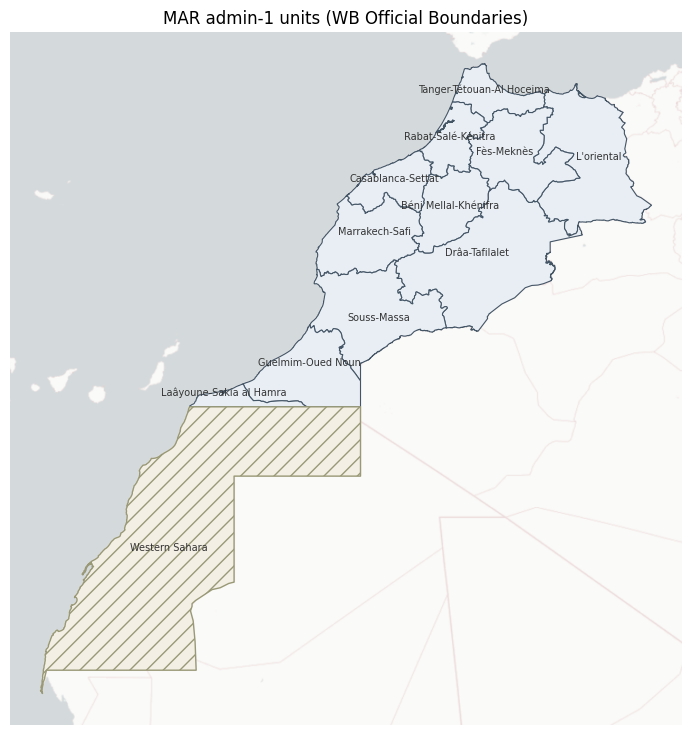

In [2]:
adm1 = admin1(TARGET_ISO)
include_esh = (adm1['ADM1CD_c'] == 'ESH000').any()
adm0_union = adm1.geometry.union_all()          # clip mask for rasters
print(f'{len(adm1)} admin-1 units (ESH appended: {include_esh})')
ax = plot_admin1(adm1, title=f'{TARGET_ISO} admin-1 units (WB Official Boundaries)')
add_basemap(ax)

## GAR15 - UNISDR Global Exposure Dataset (GEG-15)

Per-country point grid from HDX; `tot_val` is capital stock of buildings in **millions of
2005 US$** (WB CWON 2011 produced capital - structures, no contents; per the GEG-15 metadata
PDF; input data vintage ~2011). For MAR the companion Western Sahara dataset is appended.

GAR15 capital stock: $600.8B (constant 2025 US$; $380.0B nominal 2005 US$)


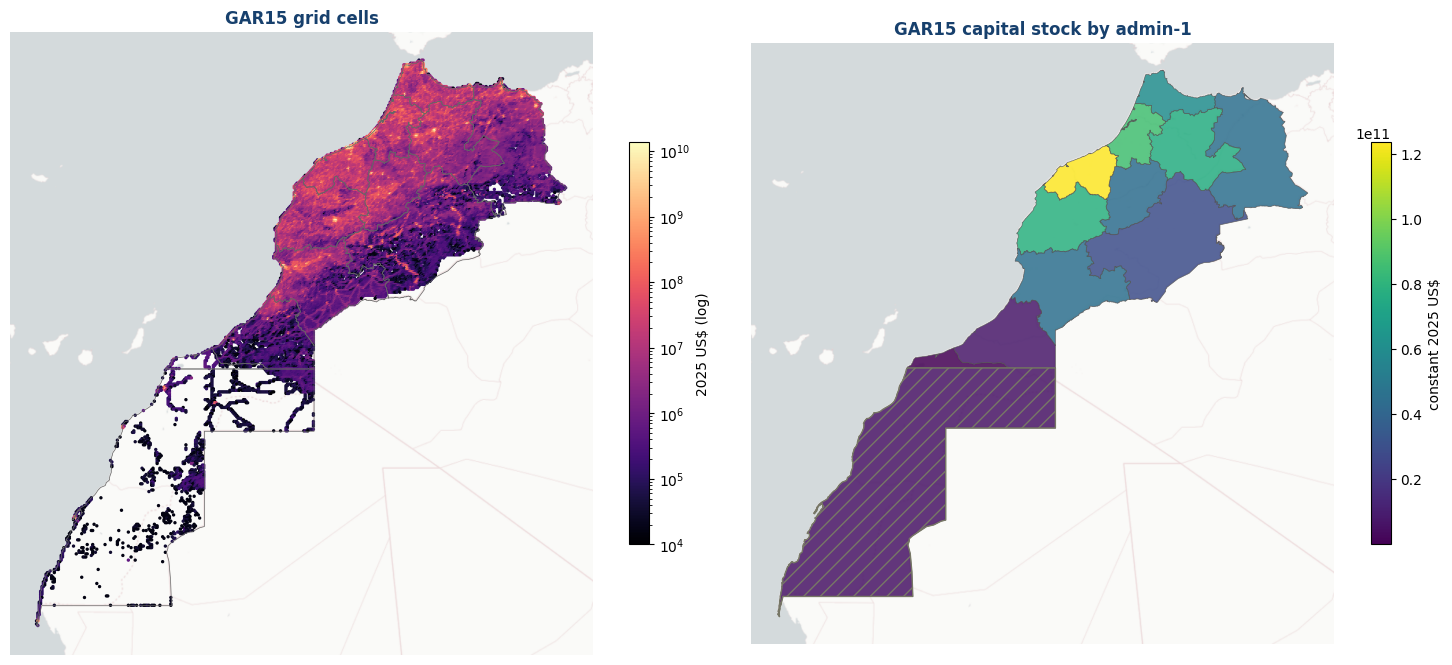

In [3]:
g15 = gar15.load(TARGET_ISO, include_esh=include_esh)
gar15_adm1 = util.points_to_adm1(
    g15, adm1, ['gar15_usd', 'gar15_urban_usd', 'gar15_rural_usd'],
    nearest_max_deg=0.1)
for c in ['gar15_usd', 'gar15_urban_usd', 'gar15_rural_usd']:
    gar15_adm1[c + '_adj'] = gar15_adm1[c] * F['gar15']
gar15_total = gar15_adm1['gar15_usd_adj'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
pos = g15[g15['gar15_usd'] > 0].to_crs(adm1.crs)
pos = pos.assign(gar15_usd_adj=pos['gar15_usd'] * F['gar15'])
pos.plot(ax=axes[0], column='gar15_usd_adj', markersize=2, cmap='magma',
         norm=LogNorm(vmin=max(pos['gar15_usd_adj'].min(), 1e4),
                      vmax=pos['gar15_usd_adj'].max()), zorder=2,
         legend=True, legend_kwds={'shrink': 0.6, 'label': f'{USD_YEAR} US$ (log)'})
adm1.boundary.plot(ax=axes[0], color='#666', linewidth=0.5, zorder=3)
add_basemap(axes[0])
style_map(axes[0], 'GAR15 grid cells')
choropleth(gar15_adm1, 'gar15_usd_adj', 'GAR15 capital stock by admin-1',
           f'constant {USD_YEAR} US$', ax=axes[1])
plt.tight_layout()

print(f'GAR15 capital stock: {usd(gar15_total)} (constant {USD_YEAR} US$; '
      f'{usd(gar15_adm1["gar15_usd"].sum())} nominal 2005 US$)')

## GIRI - Building Exposure Model (BEM)

Global 5x5 km rasters of building stock value (**2018 US$**; structures, no contents; input
data vintage ~2020). Cells are assigned to the ADM1 unit they overlap most; the raster panel
is **clipped to the ADM0 boundary**.

GIRI building stock (constant 2025 US$): total $537.7B | res $171.8B | non-res $365.9B


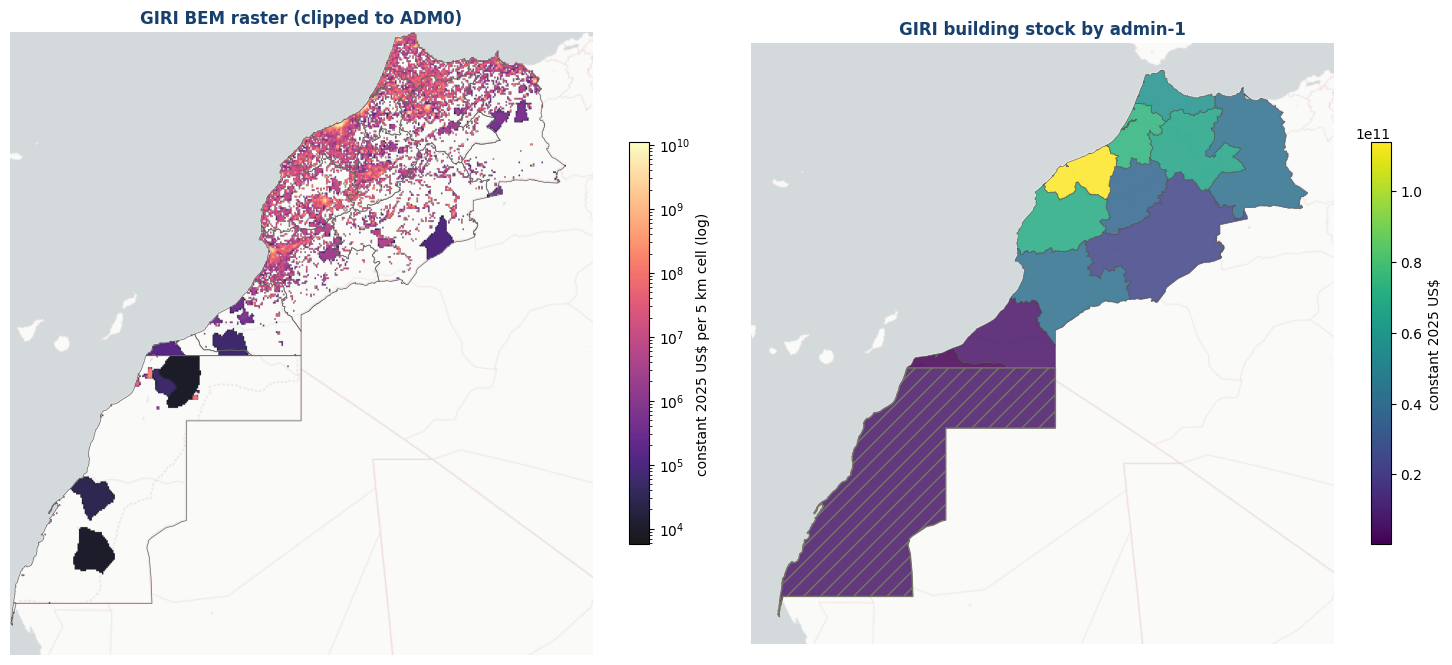

In [4]:
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds as t_from_bounds

bounds = tuple(adm1.total_bounds)
cells = giri.load_cells(bounds)
giri_cols = ['giri_total_usd', 'giri_res_usd', 'giri_nres_usd']
giri_adm1 = util.cells_to_adm1(cells, adm1, giri_cols)
for c in giri_cols:
    giri_adm1[c + '_adj'] = giri_adm1[c] * F['giri']
giri_tot = giri_adm1[[c + '_adj' for c in giri_cols]].sum()

arr, extent = giri.read_window(bounds)
arr = arr * F['giri']
transform = t_from_bounds(extent[0], extent[2], extent[1], extent[3],
                          arr.shape[1], arr.shape[0])
outside = geometry_mask([adm0_union], out_shape=arr.shape,
                        transform=transform, invert=False)
arr[outside] = np.nan            # clip to ADM0 (drops Algeria/Canaries)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
shown = np.where(arr > 0, arr, np.nan)
im = axes[0].imshow(shown, extent=extent, cmap='magma', norm=LogNorm(),
                    alpha=0.9, zorder=2)
adm1.boundary.plot(ax=axes[0], color='#666', linewidth=0.5, zorder=3)
add_basemap(axes[0])
plt.colorbar(im, ax=axes[0], shrink=0.6,
             label=f'constant {USD_YEAR} US$ per 5 km cell (log)')
style_map(axes[0], 'GIRI BEM raster (clipped to ADM0)')
choropleth(giri_adm1, 'giri_total_usd_adj', 'GIRI building stock by admin-1',
           f'constant {USD_YEAR} US$', ax=axes[1])
plt.tight_layout()

print(f'GIRI building stock (constant {USD_YEAR} US$): '
      f'total {usd(giri_tot["giri_total_usd_adj"])} | '
      f'res {usd(giri_tot["giri_res_usd_adj"])} | '
      f'non-res {usd(giri_tot["giri_nres_usd_adj"])}')

## GEM - Global Exposure Model, v2023.1.1 and v2026.0.0

Bottom-up replacement-cost model, both releases labelled separately: **v2023.1.1** (June
2023, 2021 US$, per-country ADM1 files, no urban/rural split) and **v2026.0.0** (June 2026,
costs re-based to 2024-25, stock updated to 2025, urban/rural for residential only). Both
exclude contents. GEM regions are matched to WB Admin-1 (by region code for v2026, by
normalised region name for v2023 whose codes are GADM-style); GEM's two southern regions map
to the WB Western Sahara unit.

GEM building replacement (constant 2025 US$, excl. contents):
  v2023.1.1  $224.3B | 8,258,372 buildings | 785 Mm2
  v2026.0.0  $279.0B | 8,916,394 buildings | 849 Mm2


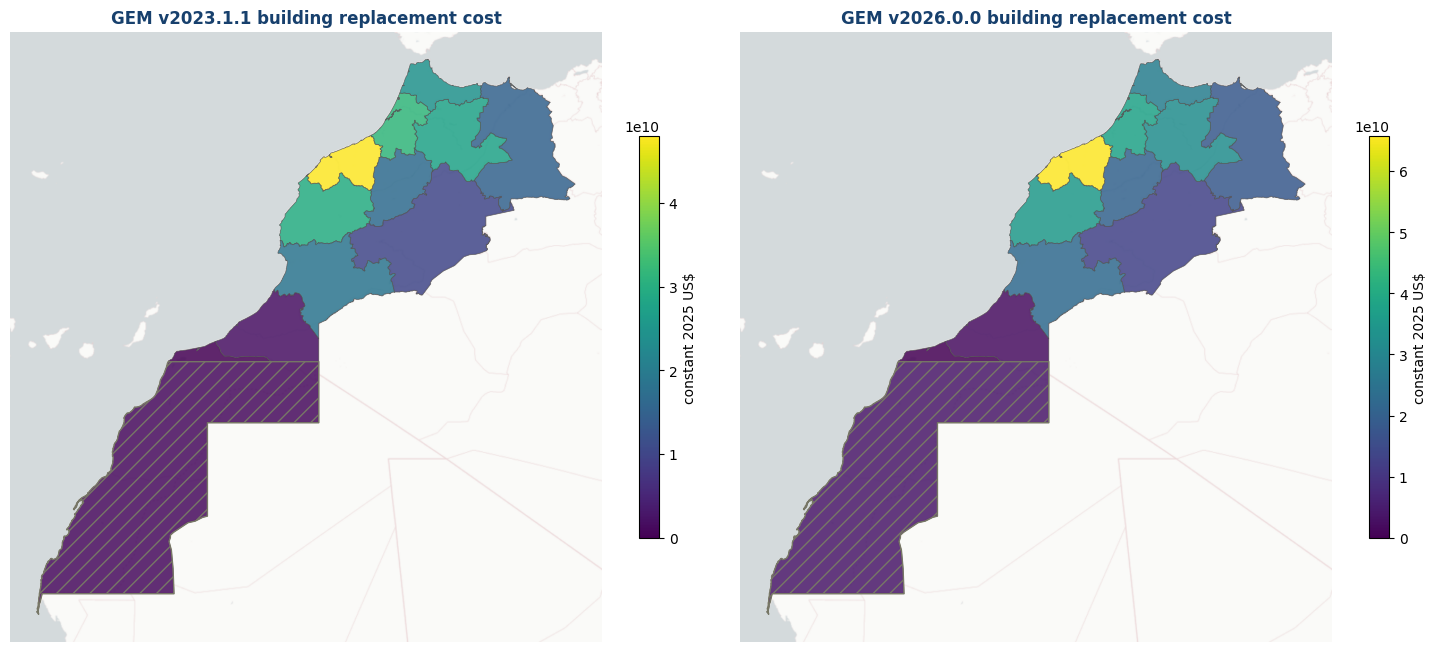

In [5]:
gem23 = adm1.merge(gem.adm1_totals_2023(gem.load_2023(TARGET_ISO), TARGET_ISO),
                   on='ADM1CD_c', how='left').fillna(0.0)
gem26_df = gem.load(TARGET_ISO)
gem26 = adm1.merge(gem.adm1_totals(gem26_df, TARGET_ISO),
                   on='ADM1CD_c', how='left').fillna(0.0)
for g_, f_ in ((gem23, F['gem2023']), (gem26, F['gem2026'])):
    for c in [c for c in g_.columns if c.endswith('_usd')]:
        g_[c + '_adj'] = g_[c] * f_

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
choropleth(gem23, 'gem23_bldg_repl_usd_adj',
           'GEM v2023.1.1 building replacement cost',
           f'constant {USD_YEAR} US$', ax=axes[0])
choropleth(gem26, 'gem26_bldg_repl_usd_adj',
           'GEM v2026.0.0 building replacement cost',
           f'constant {USD_YEAR} US$', ax=axes[1])
plt.tight_layout()

print(f'GEM building replacement (constant {USD_YEAR} US$, excl. contents):')
print(f'  v2023.1.1  {usd(gem23["gem23_bldg_repl_usd_adj"].sum())} | '
      f'{gem23["gem23_buildings"].sum():,.0f} buildings | '
      f'{gem23["gem23_floor_area_m2"].sum() / 1e6:,.0f} Mm2')
print(f'  v2026.0.0  {usd(gem26["gem26_bldg_repl_usd_adj"].sum())} | '
      f'{gem26["gem26_buildings"].sum():,.0f} buildings | '
      f'{gem26["gem26_floor_area_m2"].sum() / 1e6:,.0f} Mm2')

## Global Building Atlas (GBA) LoD1 - footprints + heights

5-degree parquet tiles from source.coop; heights drive floor area via the 3-tier storey
divisor (3.0 / 3.25 / 3.5 m); missing heights count as one storey. The only footprint source
with modelled heights - it also **calibrates the storey multipliers** used for Overture and
Microsoft below (floor/footprint ratio per ADM1 x urban/rural class).

GBA: 4,647,467 buildings | 2,208 Mm2 floor | est. value $725.4B
storey multipliers (floor/footprint): urban 2.38x, rural 1.06x


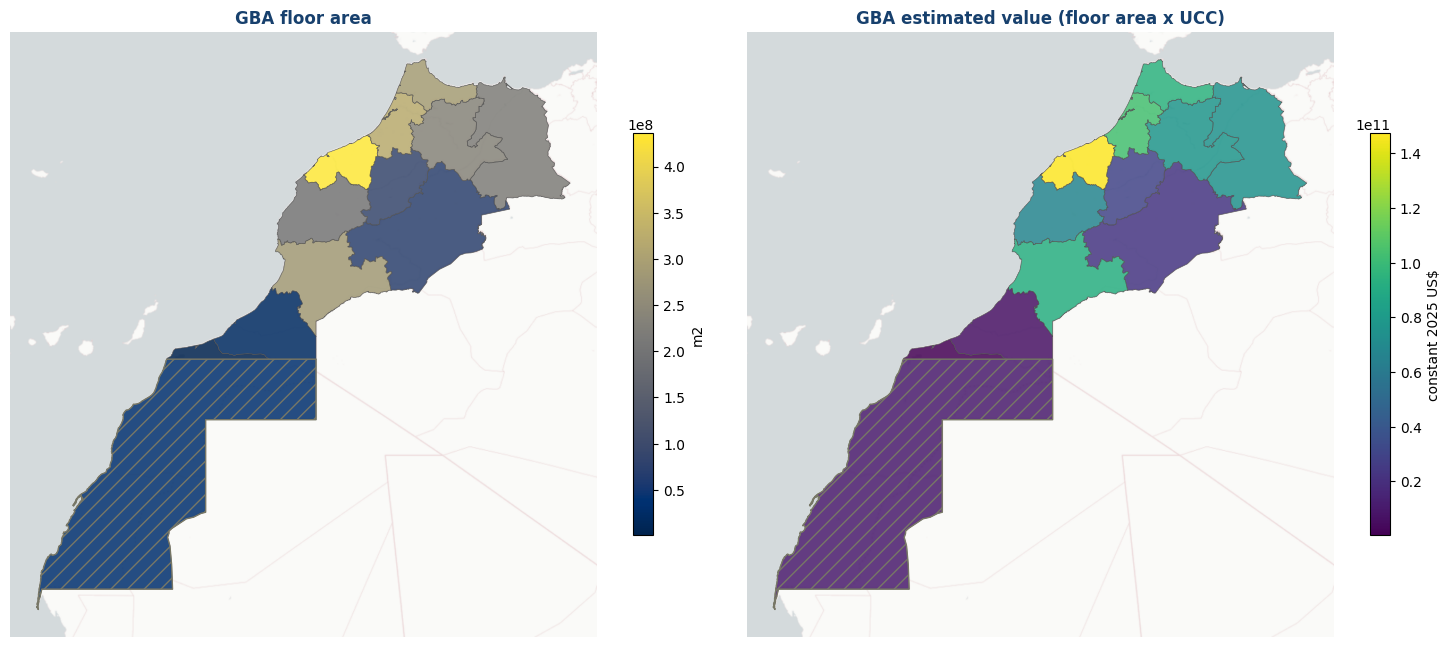

In [6]:
ucc_rate = ucc.adm1_ucc(TARGET_ISO, list(adm1['ADM1CD_c']))

gba_adm1 = adm1.merge(buildings.extract_gba(TARGET_ISO, adm1),
                      on='ADM1CD_c', how='left').fillna(0.0)

def add_value(out, prefix):
    rate = out['ADM1CD_c'].map(ucc_rate)
    for s in ('', '_urban', '_rural'):
        out[f'{prefix}_value_usd{s}'] = out[f'{prefix}_floor_area_m2{s}'] * rate
        out[f'{prefix}_value_usd{s}_adj'] = out[f'{prefix}_value_usd{s}'] * F['ucc']
    return out

gba_adm1 = add_value(gba_adm1, 'gba')

# storey multipliers for the footprint-only datasets (per ADM1 x class)
MULT = {}
for s in ('', '_urban', '_rural'):
    fp = gba_adm1[f'gba_footprint_m2{s}']
    nat = gba_adm1['gba_floor_area_m2'].sum() / gba_adm1['gba_footprint_m2'].sum()
    MULT[s] = (gba_adm1[f'gba_floor_area_m2{s}'] / fp.where(fp > 0)).fillna(nat)
    MULT[s].index = gba_adm1['ADM1CD_c']

def estimate_floor(out, prefix):
    """floor_known + fp_unknown x GBA storey multiplier, then UCC value."""
    for s in ('', '_urban', '_rural'):
        out[f'{prefix}_floor_area_m2{s}'] = (
            out[f'{prefix}_floor_known_m2{s}']
            + out[f'{prefix}_fp_unknown_m2{s}'] * out['ADM1CD_c'].map(MULT[s]))
    return add_value(out, prefix)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
choropleth(gba_adm1, 'gba_floor_area_m2', 'GBA floor area',
           'm2', cmap='cividis', ax=axes[0])
choropleth(gba_adm1, 'gba_value_usd_adj',
           'GBA estimated value (floor area x UCC)',
           f'constant {USD_YEAR} US$', ax=axes[1])
plt.tight_layout()

print(f'GBA: {gba_adm1["gba_buildings"].sum():,.0f} buildings | '
      f'{gba_adm1["gba_floor_area_m2"].sum() / 1e6:,.0f} Mm2 floor | '
      f'est. value {usd(gba_adm1["gba_value_usd_adj"].sum())}')
print('storey multipliers (floor/footprint): urban '
      f'{gba_adm1["gba_floor_area_m2_urban"].sum() / gba_adm1["gba_footprint_m2_urban"].sum():.2f}x, '
      f'rural {gba_adm1["gba_floor_area_m2_rural"].sum() / gba_adm1["gba_footprint_m2_rural"].sum():.2f}x')

## Overture Maps - building footprints

Aggregated inside DuckDB against the pinned S3 release. `num_floors`/`height` are used where
present (rare in Morocco); the unattributed footprint gets the **GBA-calibrated storey
multiplier** above. Value estimated as floor area x GEM ADM1 UCC.

Overture: 4,092,370 buildings | 1,609 Mm2 est. floor | est. value $527.5B
floor area from reported attributes: 42 Mm2 (attributes exist on a small share of buildings; the rest uses GBA storeys)


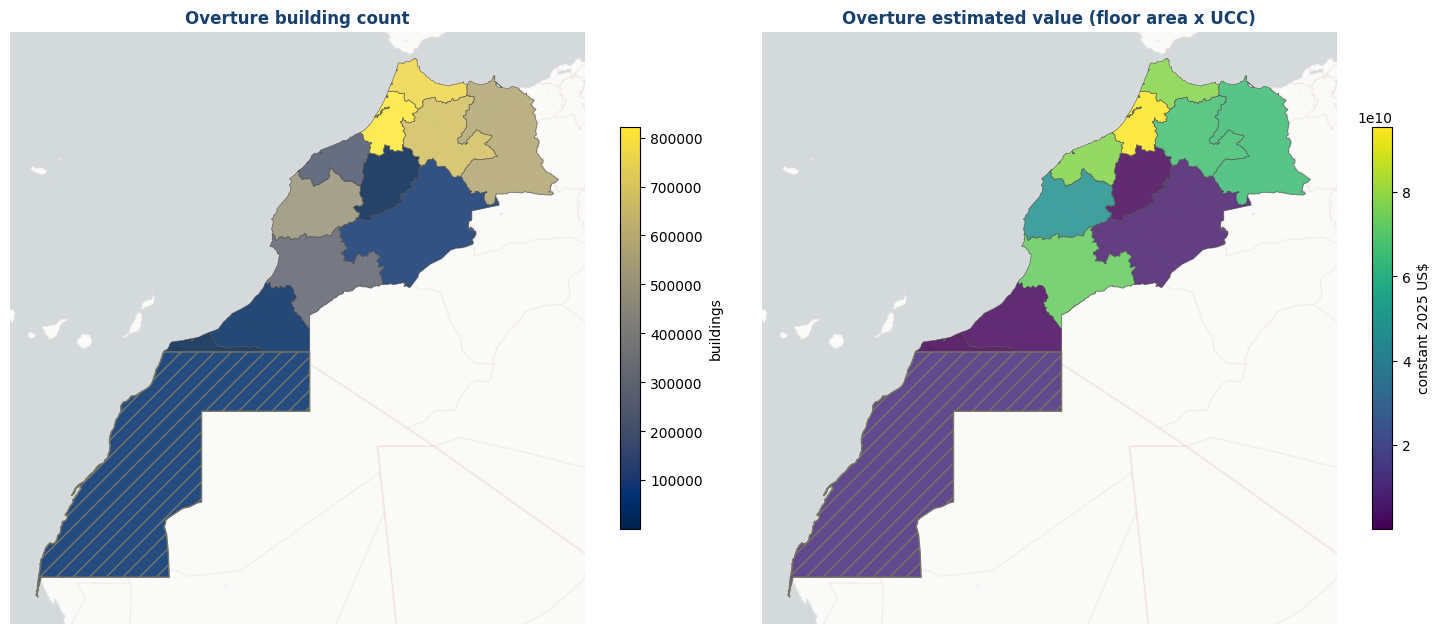

In [7]:
overture_adm1 = estimate_floor(
    adm1.merge(buildings.extract_overture(TARGET_ISO, adm1),
               on='ADM1CD_c', how='left').fillna(0.0), 'overture')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
choropleth(overture_adm1, 'overture_buildings', 'Overture building count',
           'buildings', cmap='cividis', ax=axes[0])
choropleth(overture_adm1, 'overture_value_usd_adj',
           'Overture estimated value (floor area x UCC)',
           f'constant {USD_YEAR} US$', ax=axes[1])
plt.tight_layout()

known = overture_adm1['overture_floor_known_m2'].sum()
tot_fp = overture_adm1['overture_footprint_m2'].sum()
print(f'Overture: {overture_adm1["overture_buildings"].sum():,.0f} buildings | '
      f'{overture_adm1["overture_floor_area_m2"].sum() / 1e6:,.0f} Mm2 est. floor | '
      f'est. value {usd(overture_adm1["overture_value_usd_adj"].sum())}')
print(f'floor area from reported attributes: {known / 1e6:,.0f} Mm2 '
      f'(attributes exist on a small share of buildings; the rest uses GBA storeys)')

## Microsoft Buildings - GlobalML footprints

Native Microsoft GlobalML release (98 quadkey files for Morocco). The schema carries a
per-building `height`, but it is **unmodelled (-1) throughout Morocco**, so floor areas come
entirely from the GBA-calibrated storey multipliers. An independent ML footprint extraction
(Overture ingests an earlier Microsoft layer) - a useful redundancy check.

Microsoft: 3,358,606 buildings | 728 Mm2 footprint | 1,271 Mm2 est. floor | est. value $417.2B


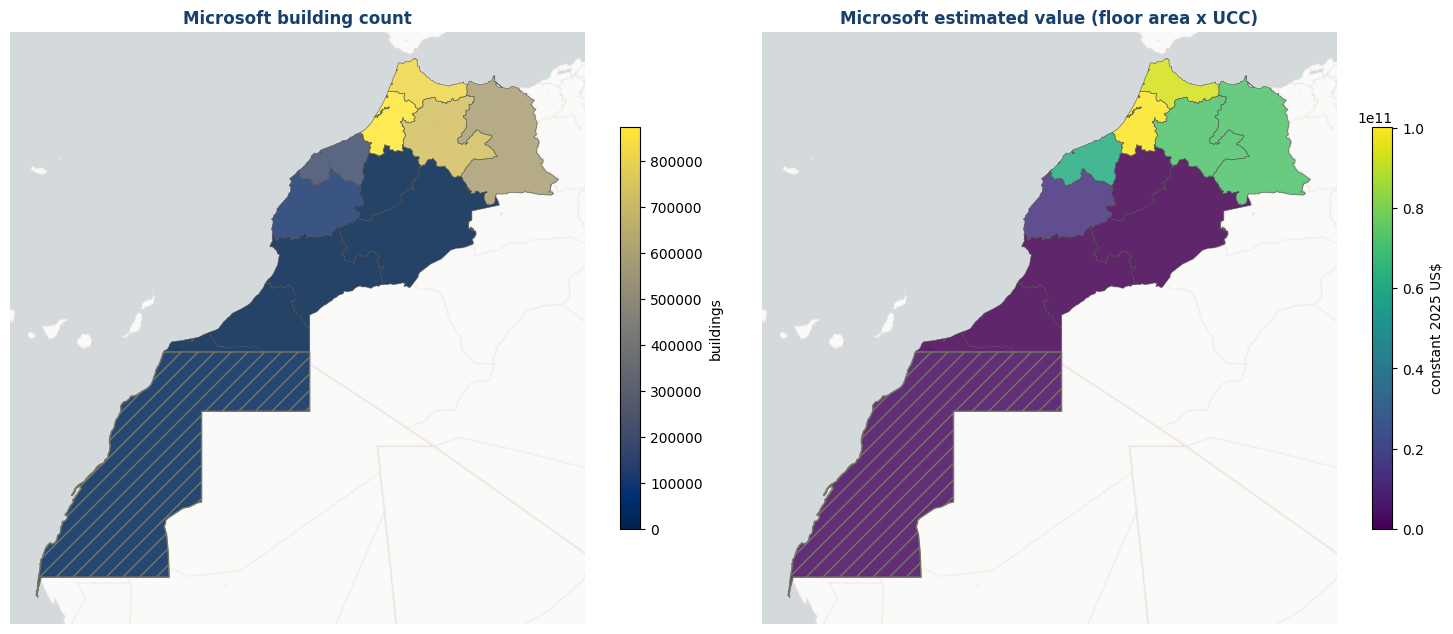

In [8]:
msb_adm1 = estimate_floor(
    adm1.merge(buildings.extract_msb(TARGET_ISO, adm1),
               on='ADM1CD_c', how='left').fillna(0.0), 'msb')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
choropleth(msb_adm1, 'msb_buildings', 'Microsoft building count',
           'buildings', cmap='cividis', ax=axes[0])
choropleth(msb_adm1, 'msb_value_usd_adj',
           'Microsoft estimated value (floor area x UCC)',
           f'constant {USD_YEAR} US$', ax=axes[1])
plt.tight_layout()

print(f'Microsoft: {msb_adm1["msb_buildings"].sum():,.0f} buildings | '
      f'{msb_adm1["msb_footprint_m2"].sum() / 1e6:,.0f} Mm2 footprint | '
      f'{msb_adm1["msb_floor_area_m2"].sum() / 1e6:,.0f} Mm2 est. floor | '
      f'est. value {usd(msb_adm1["msb_value_usd_adj"].sum())}')

## Compilation - totals in constant US$

All values in constant latest-year US$ (nominal alongside). GEM contents are dropped
(GAR15/GIRI are structures-only).

,source,metric,price_year,nominal_usd,factor,constant_2025_usd
0,GAR15,capital stock (structures),2005,3.8e+11,1.581,6.01e+11
1,GIRI BEM,"building stock, total",2018,4.27e+11,1.261,5.38e+11
2,GIRI BEM,residential,2018,1.36e+11,1.261,1.72e+11
3,GIRI BEM,non-residential,2018,2.9e+11,1.261,3.66e+11
4,GEM v2023,bldg replacement (excl. contents),2021,1.92e+11,1.170,2.24e+11
5,GEM v2026,bldg replacement (excl. contents),2024,2.71e+11,1.028,2.79e+11
6,Overture,estimated (floor x UCC),2024,5.13e+11,1.028,5.28e+11
7,GBA,estimated (floor x UCC),2024,7.06e+11,1.028,7.25e+11
8,Microsoft,estimated (floor x UCC),2024,4.06e+11,1.028,4.17e+11


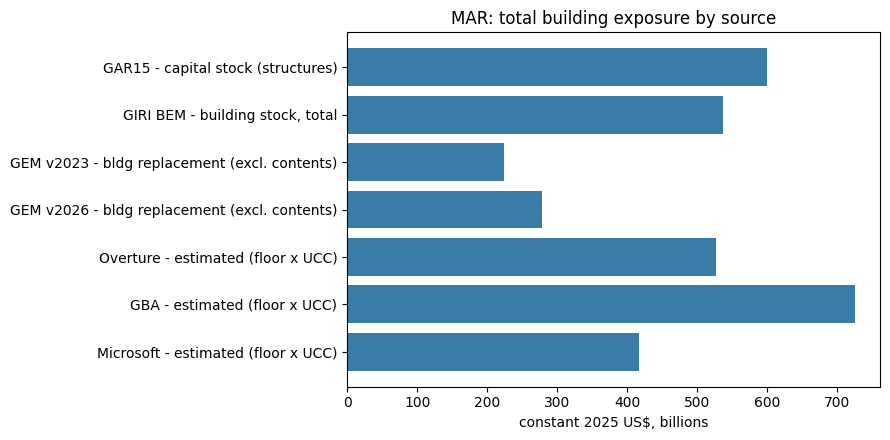

In [9]:
vy = deflate.VALUE_YEARS
rows = [
    ('GAR15',      'capital stock (structures)',        vy['gar15'],   gar15_adm1['gar15_usd'].sum()),
    ('GIRI BEM',   'building stock, total',             vy['giri'],    giri_adm1['giri_total_usd'].sum()),
    ('GIRI BEM',   'residential',                       vy['giri'],    giri_adm1['giri_res_usd'].sum()),
    ('GIRI BEM',   'non-residential',                   vy['giri'],    giri_adm1['giri_nres_usd'].sum()),
    ('GEM v2023',  'bldg replacement (excl. contents)', vy['gem2023'], gem23['gem23_bldg_repl_usd'].sum()),
    ('GEM v2026',  'bldg replacement (excl. contents)', vy['gem2026'], gem26['gem26_bldg_repl_usd'].sum()),
    ('Overture',   'estimated (floor x UCC)',           vy['ucc'],     overture_adm1['overture_value_usd'].sum()),
    ('GBA',        'estimated (floor x UCC)',           vy['ucc'],     gba_adm1['gba_value_usd'].sum()),
    ('Microsoft',  'estimated (floor x UCC)',           vy['ucc'],     msb_adm1['msb_value_usd'].sum()),
]
value_tbl = pd.DataFrame(rows, columns=['source', 'metric', 'price_year', 'nominal_usd'])
value_tbl['factor'] = value_tbl['price_year'].map(deflate.factor).round(3)
value_tbl[f'constant_{USD_YEAR}_usd'] = value_tbl['nominal_usd'] * value_tbl['factor']

totals_main = value_tbl[value_tbl['metric'].isin(
    ['capital stock (structures)', 'building stock, total',
     'bldg replacement (excl. contents)', 'estimated (floor x UCC)'])]
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = totals_main['source'] + ' - ' + totals_main['metric']
ax.barh(labels, totals_main[f'constant_{USD_YEAR}_usd'] / 1e9, color='#3a7ca5')
ax.set_xlabel(f'constant {USD_YEAR} US$, billions')
ax.invert_yaxis()
ax.set_title(f'{TARGET_ISO}: total building exposure by source')
plt.tight_layout()

os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
value_tbl.to_csv(os.path.join(OUTPUTS_DIR, f'exposure_totals_{TARGET_ISO.lower()}.csv'), index=False)
wide = adm1.drop(columns='geometry')
for d in (gar15_adm1, giri_adm1, gem23, gem26, overture_adm1, gba_adm1, msb_adm1):
    cols = [c for c in d.columns if c not in wide.columns and c != 'geometry']
    wide = wide.merge(d[['ADM1CD_c'] + cols], on='ADM1CD_c', how='left')
wide.to_csv(os.path.join(OUTPUTS_DIR, f'exposure_adm1_{TARGET_ISO.lower()}.csv'), index=False)
fig.savefig(os.path.join(FIGURES_DIR, f'exposure_comparison_{TARGET_ISO.lower()}.png'),
            dpi=200, bbox_inches='tight')

display(value_tbl.assign(
    nominal_usd=value_tbl['nominal_usd'].map('{:,.3g}'.format),
    **{f'constant_{USD_YEAR}_usd': value_tbl[f'constant_{USD_YEAR}_usd'].map('{:,.3g}'.format)}))

## Vintage reconciliation - does data age explain the gaps?

Separate from the base comparison: each dataset describes the stock of a different year
(GAR15 ~2011, GIRI ~2020, GBA ~2023, GEM v2026 2025). Instead of an assumed flat rate, the
growth bases are **data-driven**: values grow along the **WB Wealth Accounts
produced-capital series** for the country (`NW.PCA.TO`, real chained 2019 US$ - the same
CWON data GAR15/GIRI derive from; ~5.7%/yr recently for Morocco, extrapolated at the
trailing-10y CAGR beyond 2020), and floor areas grow at the **GHSL Built-up Volume** rate
(~1.5%/yr; physical proxy - capital growth includes deepening/quality that floor space does
not). If age explained the differences, the adjusted totals would converge.

value growth: WB produced capital (NW.PCA.TO), trailing CAGR 5.73%/yr
floor growth: GHSL Built-up Volume 2010-2020, 1.47%/yr


,source,key,constant_usd,data_vintage,growth_factor,grown_to_2025
0,GAR15,gar15,6.01e+11,2011,2.155,1.29e+12
1,GIRI,giri,5.38e+11,2020,1.321,7.1e+11
2,GEM v2023,gem2023,2.24e+11,2023,1.118,2.51e+11
3,GEM v2026,gem2026,2.79e+11,2025,1.000,2.79e+11
4,GBA est.,gba,7.25e+11,2023,1.118,8.11e+11


Takeaway: growing GAR15 along its own CWON source series OVERSHOOTS GIRI ->
the gaps are building-share method, not vintage. Floor areas barely move at
1.5%/yr; x1.00 factors mean the data already reflects 2025.


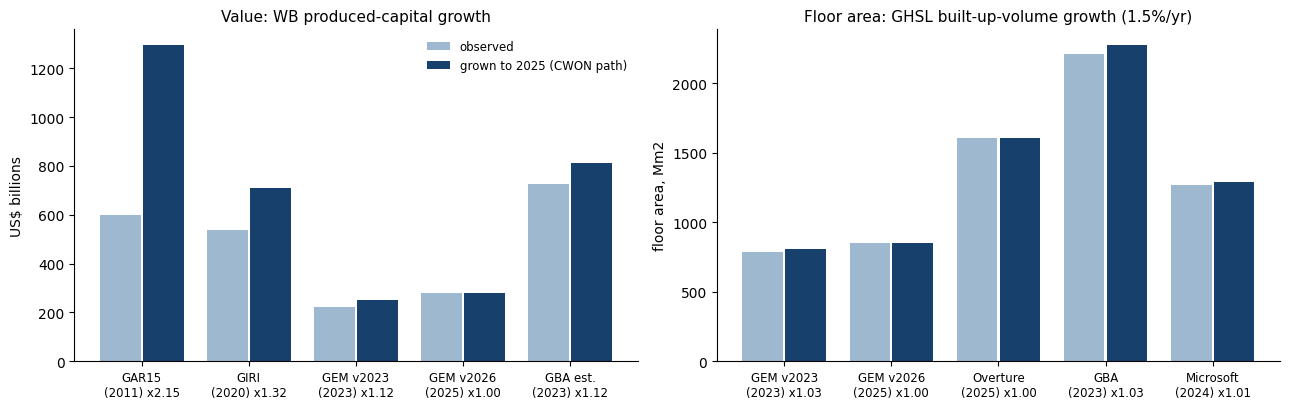

In [10]:
VIN = deflate.VINTAGE_YEARS
v_cagr = deflate.capital_cagr(TARGET_ISO)
f_rate = deflate.builtv_growth_rate(TARGET_ISO)
print(f'value growth: WB produced capital (NW.PCA.TO), trailing CAGR {v_cagr:.2%}/yr')
print(f'floor growth: GHSL Built-up Volume 2010-2020, {f_rate:.2%}/yr')

vint = [
    ('GAR15',     'gar15',   gar15_total),
    ('GIRI',      'giri',    giri_tot['giri_total_usd_adj']),
    ('GEM v2023', 'gem2023', gem23['gem23_bldg_repl_usd_adj'].sum()),
    ('GEM v2026', 'gem2026', gem26['gem26_bldg_repl_usd_adj'].sum()),
    ('GBA est.',  'gba',     gba_adm1['gba_value_usd_adj'].sum()),
]
vt = pd.DataFrame(vint, columns=['source', 'key', 'constant_usd'])
vt['data_vintage'] = vt['key'].map(VIN)
vt['growth_factor'] = vt['key'].map(
    lambda k: deflate.capital_growth_factor(TARGET_ISO, VIN[k], USD_YEAR)).round(3)
vt[f'grown_to_{USD_YEAR}'] = vt['constant_usd'] * vt['growth_factor']

fl = [
    ('GEM v2023', 'gem2023',  gem23['gem23_floor_area_m2'].sum()),
    ('GEM v2026', 'gem2026',  gem26['gem26_floor_area_m2'].sum()),
    ('Overture',  'overture', overture_adm1['overture_floor_area_m2'].sum()),
    ('GBA',       'gba',      gba_adm1['gba_floor_area_m2'].sum()),
    ('Microsoft', 'msb',      msb_adm1['msb_floor_area_m2'].sum()),
]
ft = pd.DataFrame(fl, columns=['source', 'key', 'floor_m2'])
ft['data_vintage'] = ft['key'].map(VIN)
ft['growth_factor'] = ft['key'].map(
    lambda k: deflate.floor_growth_factor(TARGET_ISO, VIN[k], USD_YEAR)).round(3)
ft[f'grown_to_{USD_YEAR}'] = ft['floor_m2'] * ft['growth_factor']

NL = chr(10)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(len(vt))
axes[0].bar(x - 0.2, vt['constant_usd'] / 1e9, width=0.38, color='#9db8cf',
            label='observed')
axes[0].bar(x + 0.2, vt[f'grown_to_{USD_YEAR}'] / 1e9, width=0.38,
            color='#17406D', label=f'grown to {USD_YEAR} (CWON path)')
axes[0].set_xticks(x, [f"{s}{NL}({v}) x{g:.2f}" for s, v, g in
                       zip(vt['source'], vt['data_vintage'], vt['growth_factor'])],
                   fontsize=8.5)
axes[0].set_ylabel('US$ billions')
axes[0].legend(frameon=False, fontsize=8.5)
axes[0].set_title('Value: WB produced-capital growth', fontsize=11)
x = np.arange(len(ft))
axes[1].bar(x - 0.2, ft['floor_m2'] / 1e6, width=0.38, color='#9db8cf')
axes[1].bar(x + 0.2, ft[f'grown_to_{USD_YEAR}'] / 1e6, width=0.38, color='#17406D')
axes[1].set_xticks(x, [f"{s}{NL}({v}) x{g:.2f}" for s, v, g in
                       zip(ft['source'], ft['data_vintage'], ft['growth_factor'])],
                   fontsize=8.5)
axes[1].set_ylabel('floor area, Mm2')
axes[1].set_title(f'Floor area: GHSL built-up-volume growth ({f_rate:.1%}/yr)',
                  fontsize=11)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

display(vt.assign(constant_usd=vt['constant_usd'].map('{:,.3g}'.format),
                  **{f'grown_to_{USD_YEAR}': vt[f'grown_to_{USD_YEAR}'].map('{:,.3g}'.format)}))
print('Takeaway: growing GAR15 along its own CWON source series OVERSHOOTS GIRI ->')
print('the gaps are building-share method, not vintage. Floor areas barely move at')
print(f'{f_rate:.1%}/yr; x1.00 factors mean the data already reflects {USD_YEAR}.')

## Sources and caveats

- **Contents**: GAR15 (2005 US$ produced capital, "machinery and structures") and GIRI BEM
  (2018 US$ produced capital -> building stock) do **not** include contents, so GEM is
  compared *excluding* its separately-published contents column.
- **Price years**: aligned with the WDI US GDP deflator (`NY.GDP.DEFL.ZS`, USA), cached
  under `Source Data/WDI`. GEM v2026 costs are 2024-25 based per its release notes.
- **Storey estimation**: Overture/Microsoft floor areas use reported attributes where
  present + GBA-calibrated multipliers (floor/footprint per ADM1 x urban/rural) elsewhere.
- **Estimated values** = floor area x GEM-derived ADM1 UCC
  ([UCC-database](https://github.com/aaronopdyke/UCC-database), 2024 US$, excl. contents).
- Zonal methodology (centroid / largest-overlap / region matching) documented in
  `src/util.py`, `src/gem.py` and on the
  [site About page](https://aaronopdyke.github.io/exposure-analytics/about.html).